# Offline Compare SmolVLA Old vs New

Notebook này dùng để trả lời câu hỏi: tại sao model 50 eps / ~18K steps có vẻ ổn, còn model train nhiều data/steps hơn lại hay lừng khừng hoặc trôi về pose trung tính/safe-like.

Nó làm 3 việc:

1. Tải đúng revision dataset/model từ Hugging Face.
2. So phân phối action/state của dataset 50 eps và dataset mới.
3. Lấy cùng một observation start-pose, chạy old/new model nhiều seed offline, rồi so variance, trajectory, và khoảng cách tới safe pose.

Chạy từ root repo trên server bằng Jupyter hoặc VS Code notebook. Nếu chạy bằng shell trước, nên dùng cùng env: `uv run jupyter lab`.

## 0. Parameters

Quan trọng: đổi `NEW_MODEL_REV` sang exact commit của checkpoint 150K nếu bạn không muốn dùng `main`.

In [1]:
from pathlib import Path
import json
import math
import os
import gc

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from huggingface_hub import snapshot_download

MODEL_REPO = "di-techinnova/smolvla-pouring-0.3-cutted"
OLD_MODEL_REV = "05ac253662f8d9587a66cea8c18d6dbf68ae118e"  # 50 eps / ~18K steps, adjust if needed
NEW_MODEL_REV = "main"  # set exact 150K commit here when known

DATASET_REPO = "di-techinnova/so-arm-101-pouring-0.3-cutted"
OLD_DATASET_REV = "e50117a63cf93246efa5326b07ccda0699bb7fea"  # 50 eps snapshot
NEW_DATASET_REV = "1e24a69dbf1fbf602bb71f47f47043d2c2756eaf"  # safe-pose-fixed 175 eps snapshot

CACHE_DIR = Path.home() / "lerobot" / "xai_offline_compare_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VIDEO_BACKEND = "pyav"
N_SAMPLES = 20
SEEDS = list(range(1000, 1000 + N_SAMPLES))

# Test both strings. The training task in your record command used "into".
TASKS_TO_TEST = [
    "Pour from orange cup into blue cup.",
    "Pour from orange cup to blue cup.",
]

# Pick start frames from the fixed dataset. Use episodes from file-000 and also a few later ones.
EPISODES_TO_PROBE = [0, 1, 2, 10, 50, 51, 120, 145]
FRAME_INDEX_IN_EPISODE = 0

JOINT_NAMES = [
    "shoulder_pan.pos",
    "shoulder_lift.pos",
    "elbow_flex.pos",
    "wrist_flex.pos",
    "wrist_roll.pos",
    "gripper.pos",
]
SAFE_POSE = np.array([-5.626373626373627, -104.13186813186813, 96.61538461538461, 73.89010989010988, 0.3076923076923077, 0.4098360655737705], dtype=np.float64)

print("DEVICE", DEVICE)
print("CACHE_DIR", CACHE_DIR)


DEVICE cuda
CACHE_DIR /home/trietlm/lerobot/xai_offline_compare_cache


/home/trietlm/lerobot/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download Model/Dataset Revisions

Cell này tải về local cache. Nếu server đã có cache thì nó sẽ reuse.

In [2]:
def dl_snapshot(repo_id: str, revision: str, repo_type: str, name: str, allow_patterns=None) -> Path:
    local_dir = CACHE_DIR / name
    path = snapshot_download(
        repo_id=repo_id,
        revision=revision,
        repo_type=repo_type,
        local_dir=local_dir,
        allow_patterns=allow_patterns,
    )
    return Path(path)

old_model_dir = dl_snapshot(MODEL_REPO, OLD_MODEL_REV, "model", "old_model_50eps_18k")
new_model_dir = dl_snapshot(MODEL_REPO, NEW_MODEL_REV, "model", "new_model_candidate")
old_dataset_dir = dl_snapshot(DATASET_REPO, OLD_DATASET_REV, "dataset", "old_dataset_50eps")
new_dataset_dir = dl_snapshot(DATASET_REPO, NEW_DATASET_REV, "dataset", "new_dataset_175eps_fix")

print("old_model_dir", old_model_dir)
print("new_model_dir", new_model_dir)
print("old_dataset_dir", old_dataset_dir)
print("new_dataset_dir", new_dataset_dir)


Fetching 16 files: 100%|██████████| 16/16 [00:25<00:00,  1.57s/it]

old_model_dir /home/trietlm/lerobot/xai_offline_compare_cache/old_model_50eps_18k
new_model_dir /home/trietlm/lerobot/xai_offline_compare_cache/new_model_candidate
old_dataset_dir /home/trietlm/lerobot/xai_offline_compare_cache/old_dataset_50eps
new_dataset_dir /home/trietlm/lerobot/xai_offline_compare_cache/new_dataset_175eps_fix


Equivalent bash nếu muốn tải ngoài notebook:

```bash
uv run python - <<'PY'
from huggingface_hub import snapshot_download
snapshot_download('di-techinnova/smolvla-pouring-0.3-cutted', repo_type='model', revision='05ac253662f8d9587a66cea8c18d6dbf68ae118e')
snapshot_download('di-techinnova/smolvla-pouring-0.3-cutted', repo_type='model', revision='main')
snapshot_download('di-techinnova/so-arm-101-pouring-0.3-cutted', repo_type='dataset', revision='e50117a63cf93246efa5326b07ccda0699bb7fea')
snapshot_download('di-techinnova/so-arm-101-pouring-0.3-cutted', repo_type='dataset', revision='1e24a69dbf1fbf602bb71f47f47043d2c2756eaf')
PY
```

## 2. Dataset Distribution Check

Mục tiêu: xác nhận data mới có kéo distribution về safe pose không, hay chỉ mở rộng/đổi manifold.

In [3]:
import pyarrow.parquet as pq

def read_data_parquets(root: Path) -> pd.DataFrame:
    files = sorted((root / "data").glob("chunk-*/*.parquet"))
    if not files:
        raise FileNotFoundError(f"No data parquet under {root}")
    dfs = []
    for file in files:
        df = pq.read_table(file).to_pandas()
        df["_file"] = file.name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

old_df = read_data_parquets(old_dataset_dir)
new_df = read_data_parquets(new_dataset_dir)

def vector_col(df: pd.DataFrame, col: str) -> np.ndarray:
    return np.stack(df[col].to_numpy()).astype(np.float64)

def summarize_group(label: str, df: pd.DataFrame):
    action = vector_col(df, "action")
    state = vector_col(df, "observation.state")
    ep = df["episode_index"].to_numpy().astype(int)
    out = {
        "label": label,
        "frames": len(df),
        "episodes": df["episode_index"].nunique(),
        "action_mean": np.round(action.mean(axis=0), 3).tolist(),
        "state_mean": np.round(state.mean(axis=0), 3).tolist(),
        "action_std": np.round(action.std(axis=0), 3).tolist(),
        "state_std": np.round(state.std(axis=0), 3).tolist(),
        "mean_action_dist_safe": float(np.mean(np.linalg.norm(action - SAFE_POSE, axis=1))),
        "mean_state_dist_safe": float(np.mean(np.linalg.norm(state - SAFE_POSE, axis=1))),
    }
    return out

first50_new_df = new_df[new_df["episode_index"].astype(int) < 50]
new125_df = new_df[new_df["episode_index"].astype(int) >= 50]
file001_df = new_df[(new_df["episode_index"].astype(int) >= 50) & (new_df["episode_index"].astype(int) < 120)]
file002_df = new_df[new_df["episode_index"].astype(int) >= 120]

summary = pd.DataFrame([
    summarize_group("old_dataset_50eps", old_df),
    summarize_group("new_dataset_first50", first50_new_df),
    summarize_group("new_dataset_file001_70eps", file001_df),
    summarize_group("new_dataset_file002_55eps", file002_df),
    summarize_group("new_dataset_new125", new125_df),
])
pd.set_option("display.max_colwidth", 200)
summary

,label,frames,episodes,action_mean,state_mean,action_std,state_std,mean_action_dist_safe,mean_state_dist_safe
0,old_dataset_50eps,20887,50,"[-21.011, 11.151, 22.771, -38.447, 24.206, 4.817]","[-20.818, 13.599, 25.401, -37.895, 24.199, 5.5]","[17.212, 33.167, 39.378, 30.227, 33.78, 8.523]","[17.171, 33.452, 38.268, 30.082, 33.709, 8.077]",187.619469,187.592268
1,new_dataset_first50,20879,50,"[-21.017, 11.193, 22.742, -38.488, 24.217, 4.817]","[-20.824, 13.643, 25.374, -37.935, 24.209, 5.501]","[17.213, 33.101, 39.358, 30.159, 33.782, 8.524]","[17.171, 33.382, 38.25, 30.019, 33.712, 8.078]",187.687177,187.660086
2,new_dataset_file001_70eps,29890,70,"[-19.691, 10.076, 32.621, -47.364, 21.525, 5.421]","[-19.538, 12.44, 35.099, -46.632, 21.526, 6.067]","[19.633, 33.595, 39.438, 31.547, 31.535, 8.263]","[19.622, 34.05, 38.297, 31.526, 31.477, 7.757]",188.698206,188.660464
3,new_dataset_file002_55eps,23034,55,"[-17.596, 8.189, 29.685, -40.032, 21.395, 4.151]","[-17.459, 10.428, 32.217, -39.242, 21.417, 4.856]","[17.068, 33.709, 47.833, 33.621, 31.113, 6.714]","[17.041, 33.998, 46.587, 33.569, 31.046, 6.253]",185.506534,185.281236
4,new_dataset_new125,52924,125,"[-18.779, 9.255, 31.343, -44.173, 21.468, 4.868]","[-18.633, 11.564, 33.845, -43.416, 21.478, 5.54]","[18.59, 33.658, 43.317, 32.669, 31.352, 7.653]","[18.571, 34.042, 42.13, 32.637, 31.29, 7.166]",187.309101,187.189730


In [4]:
def episode_stats(df: pd.DataFrame) -> pd.DataFrame:
    action = vector_col(df, "action")
    state = vector_col(df, "observation.state")
    ep = df["episode_index"].to_numpy().astype(int)
    rows = []
    for episode in sorted(np.unique(ep)):
        idx = np.where(ep == episode)[0]
        aa = action[idx]
        ss = state[idx]
        da = np.linalg.norm(np.diff(aa, axis=0), axis=1) if len(idx) > 1 else np.array([0.0])
        ds = np.linalg.norm(np.diff(ss, axis=0), axis=1) if len(idx) > 1 else np.array([0.0])
        rows.append({
            "episode_index": int(episode),
            "frames": len(idx),
            "mean_action_speed": float(da.mean()),
            "mean_state_speed": float(ds.mean()),
            "start_state_dist_safe": float(np.linalg.norm(ss[0] - SAFE_POSE)),
            "end_state_dist_safe": float(np.linalg.norm(ss[-1] - SAFE_POSE)),
            "start_action_dist_safe": float(np.linalg.norm(aa[0] - SAFE_POSE)),
            "end_action_dist_safe": float(np.linalg.norm(aa[-1] - SAFE_POSE)),
            "gripper_mean": float(aa[:, 5].mean()),
            "gripper_min": float(aa[:, 5].min()),
            "gripper_max": float(aa[:, 5].max()),
        })
    return pd.DataFrame(rows)

eps = episode_stats(new_df)
eps["bucket"] = np.where(eps["episode_index"] < 50, "first50", np.where(eps["episode_index"] < 120, "file001", "file002"))
eps.groupby("bucket")[["frames", "mean_action_speed", "mean_state_speed", "start_state_dist_safe", "end_state_dist_safe", "gripper_mean", "gripper_max"]].agg(["mean", "median", "min", "max"]).round(3)

frames                  mean_action_speed                       \
           mean median  min  max              mean median    min    max   
bucket                                                                    
file001  427.00  430.0  363  450             2.337  2.330  2.000  3.002   
file002  418.80  417.0  365  450             2.454  2.465  2.090  3.033   
first50  417.58  421.5  344  450             2.556  2.583  2.139  2.943   

        mean_state_speed         ... end_state_dist_safe           \
                    mean median  ...                 min      max   
bucket                           ...                                
file001            2.231  2.207  ...              22.509  193.528   
file002            2.356  2.364  ...              19.214  167.771   
first50            2.440  2.443  ...              21.782  164.551   

        gripper_mean                       gripper_max                          
                mean median    min     max        mean  median     min     max  
bucket                                                                          
file001        5.398  4.927  2.884  11.665      23.307  22.947  16.264  37.118  
file002        4.152  4.006  2.401   6.570      21.189  20.853  15.781  28.583  
first50        4.793  4.576  3.067   7.631      28.464  28.180  18.680  40.821  

[3 rows x 28 columns]

## 3. Load Dataset Observations

Ta lấy cùng start observation để chạy nhiều sample. Dataset frame dùng video decode, nên nếu thiếu ffmpeg/pyav cần cài trước.

In [5]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

ds = LeRobotDataset(DATASET_REPO, root=new_dataset_dir, video_backend=VIDEO_BACKEND)
print(ds)

index_df = new_df[["index", "episode_index", "frame_index", "timestamp"]].copy()
index_df["episode_index"] = index_df["episode_index"].astype(int)
index_df["frame_index"] = index_df["frame_index"].astype(int)
index_df["index"] = index_df["index"].astype(int)

probe_rows = []
for ep in EPISODES_TO_PROBE:
    rows = index_df[(index_df["episode_index"] == ep) & (index_df["frame_index"] == FRAME_INDEX_IN_EPISODE)]
    if len(rows) == 0:
        print(f"skip episode {ep}: no frame {FRAME_INDEX_IN_EPISODE}")
        continue
    probe_rows.append(rows.iloc[0].to_dict())
probe_df = pd.DataFrame(probe_rows)
probe_df

LeRobotDataset({
    Repository ID: 'di-techinnova/so-arm-101-pouring-0.3-cutted',
    Number of selected episodes: '175',
    Number of selected samples: '73803',
    Features: '['action', 'observation.state', 'observation.images.camera1', 'observation.images.camera2', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})


,index,episode_index,frame_index,timestamp
0,0.0,0.0,0.0,0.0
1,439.0,1.0,0.0,0.0
2,862.0,2.0,0.0,0.0
3,4241.0,10.0,0.0,0.0
4,20879.0,50.0,0.0,0.0
5,21307.0,51.0,0.0,0.0
6,50769.0,120.0,0.0,0.0
7,61139.0,145.0,0.0,0.0


Quick visual check cho observation đầu tiên.

state [ -9.231 -99.473  96.791  73.451  -5.582   4.577]


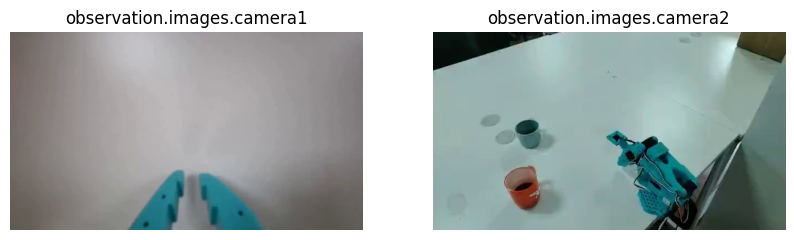

In [6]:
def show_probe(ds, global_index: int):
    item = ds[int(global_index)]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, key in zip(axes, ["observation.images.camera1", "observation.images.camera2"]):
        img = item[key]
        if isinstance(img, torch.Tensor):
            arr = img.detach().cpu()
            if arr.ndim == 3 and arr.shape[0] in (1, 3):
                arr = arr.permute(1, 2, 0)
            arr = arr.numpy()
        else:
            arr = np.asarray(img)
        ax.imshow(np.clip(arr, 0, 1) if arr.dtype.kind == 'f' else arr)
        ax.set_title(key)
        ax.axis("off")
    print("state", np.round(np.asarray(item["observation.state"]), 3))
    return item

first_probe_item = show_probe(ds, int(probe_df.iloc[0]["index"]))

## 4. Load Policies and Reproduce Server Inference Path

Dùng `from_pretrained` + `make_pre_post_processors` giống policy server. Output gồm:

- `raw_norm`: action chunk trong normalized space trước postprocessor.
- `processed`: action chunk sau unnormalize, đơn vị degree giống robot action.

In [8]:
from lerobot.policies.factory import get_policy_class, make_pre_post_processors
from lerobot.utils.constants import ACTION

policy_cls = get_policy_class("smolvla")

def load_policy_bundle(model_dir: Path, device: str):
    policy = policy_cls.from_pretrained(str(model_dir))
    policy.config.device = device
    policy.to(device)
    policy.eval()
    pre, post = make_pre_post_processors(
        policy.config,
        pretrained_path=str(model_dir),
        preprocessor_overrides={"device_processor": {"device": device}},
        postprocessor_overrides={"device_processor": {"device": device}},
    )
    print("loaded", model_dir)
    print("chunk_size", policy.config.chunk_size, "n_action_steps", policy.config.n_action_steps, "num_steps", getattr(policy.config, "num_steps", None))
    print("input_features", list(policy.config.input_features))
    return policy, pre, post

old_policy, old_pre, old_post = load_policy_bundle(old_model_dir, DEVICE)
new_policy, new_pre, new_post = load_policy_bundle(new_model_dir, DEVICE)

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Loading weights: 100%|██████████| 489/489 [00:00<00:00, 1134.81it/s]


Reducing the number of VLM layers to 16 ...
Loading weights from local directory


ProcessorMigrationError: Model '/home/trietlm/lerobot/xai_offline_compare_cache/old_model_50eps_18k' requires migration to processor format. Run: python src/lerobot/processor/migrate_policy_normalization.py --pretrained-path /home/trietlm/lerobot/xai_offline_compare_cache/old_model_50eps_18k

Original error: Config file 'policy_preprocessor.json' not found

In [ ]:
def build_obs_for_policy(item: dict, policy, task: str) -> dict:
    obs = {}
    for key in policy.config.input_features:
        if key in item:
            obs[key] = item[key]
    obs["task"] = task
    return obs

def postprocess_chunk(raw_action_tensor: torch.Tensor, postprocessor) -> torch.Tensor:
    # Matches rtc_inference.policy_server: postprocess each timestep separately.
    processed_actions = []
    _, chunk_size, _ = raw_action_tensor.shape
    for i in range(chunk_size):
        processed_action = postprocessor(raw_action_tensor[:, i, :])
        processed_actions.append(processed_action)
    return torch.stack(processed_actions, dim=1).squeeze(0).detach().cpu()

@torch.no_grad()
def infer_once(policy, preprocessor, postprocessor, item: dict, task: str, seed: int | None = None, fixed_noise: torch.Tensor | None = None):
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    obs = build_obs_for_policy(item, policy, task)
    batch = preprocessor(obs)
    kwargs = {}
    if fixed_noise is not None:
        kwargs["noise"] = fixed_noise.to(DEVICE)
    raw_norm = policy.predict_action_chunk(batch, **kwargs)
    if raw_norm.ndim != 3:
        raw_norm = raw_norm.unsqueeze(0)
    processed = postprocess_chunk(raw_norm, postprocessor)
    return {
        "raw_norm": raw_norm.detach().cpu(),
        "processed": processed,
    }

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 5. Multi-seed Inference Comparison

Nếu new model variance lớn hơn hoặc mean trajectory gần safe/neutral hơn old model trên cùng observation, đây là bằng chứng model mới bị mode averaging / under-confident.

In [ ]:
def run_probe_set(probe_df: pd.DataFrame):
    records = []
    chunks = {}
    for _, row in probe_df.iterrows():
        item = ds[int(row["index"])]
        state = np.asarray(item["observation.state"], dtype=np.float64)
        for task in TASKS_TO_TEST:
            for model_name, policy, pre, post in [
                ("old", old_policy, old_pre, old_post),
                ("new", new_policy, new_pre, new_post),
            ]:
                sample_chunks = []
                raw_chunks = []
                for seed in SEEDS:
                    out = infer_once(policy, pre, post, item, task=task, seed=seed)
                    proc = out["processed"].numpy().astype(np.float64)
                    raw = out["raw_norm"].squeeze(0).numpy().astype(np.float64)
                    sample_chunks.append(proc)
                    raw_chunks.append(raw)
                    first = proc[0]
                    records.append({
                        "episode_index": int(row["episode_index"]),
                        "frame_index": int(row["frame_index"]),
                        "global_index": int(row["index"]),
                        "task": task,
                        "model": model_name,
                        "seed": seed,
                        "first_action_dist_safe": float(np.linalg.norm(first - SAFE_POSE)),
                        "first_action_dist_state": float(np.linalg.norm(first - state)),
                        "chunk_mean_dist_safe": float(np.mean(np.linalg.norm(proc - SAFE_POSE, axis=1))),
                        "chunk_mean_dist_state": float(np.mean(np.linalg.norm(proc - state, axis=1))),
                        "first_gripper": float(first[5]),
                        "chunk_gripper_mean": float(proc[:, 5].mean()),
                    })
                chunks[(int(row["episode_index"]), task, model_name)] = {
                    "processed": np.stack(sample_chunks),
                    "raw_norm": np.stack(raw_chunks),
                    "state": state,
                }
                cleanup_cuda()
    return pd.DataFrame(records), chunks

results, chunks = run_probe_set(probe_df)
results.head()

In [ ]:
agg = results.groupby(["episode_index", "task", "model"])[[
    "first_action_dist_safe",
    "first_action_dist_state",
    "chunk_mean_dist_safe",
    "chunk_mean_dist_state",
    "first_gripper",
    "chunk_gripper_mean",
]].agg(["mean", "std", "min", "max"]).round(3)
agg

In [ ]:
# Variance of the whole chunk across stochastic samples.
variance_rows = []
for key, val in chunks.items():
    ep, task, model_name = key
    proc = val["processed"]  # [samples, T, A]
    raw = val["raw_norm"]
    variance_rows.append({
        "episode_index": ep,
        "task": task,
        "model": model_name,
        "processed_mean_std_all": float(proc.std(axis=0).mean()),
        "processed_max_std_all": float(proc.std(axis=0).max()),
        "raw_norm_mean_std_all": float(raw.std(axis=0).mean()),
        "raw_norm_max_std_all": float(raw.std(axis=0).max()),
    })
variance_df = pd.DataFrame(variance_rows).sort_values(["episode_index", "task", "model"])
variance_df.round(4)

## 6. Plot Trajectories

Mỗi subplot là một joint. Đường mảnh là từng sample, đường đậm là mean chunk. Đường ngang đỏ là safe pose joint tương ứng.

In [ ]:
def plot_compare_episode(ep: int, task: str):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    axes = axes.ravel()
    colors = {"old": "tab:blue", "new": "tab:orange"}
    for j, ax in enumerate(axes):
        for model_name in ["old", "new"]:
            key = (ep, task, model_name)
            if key not in chunks:
                continue
            proc = chunks[key]["processed"]
            for s in range(proc.shape[0]):
                ax.plot(proc[s, :, j], color=colors[model_name], alpha=0.12, linewidth=0.8)
            ax.plot(proc.mean(axis=0)[:, j], color=colors[model_name], linewidth=2.5, label=model_name)
        ax.axhline(SAFE_POSE[j], color="red", linestyle="--", linewidth=1, alpha=0.8)
        ax.set_title(JOINT_NAMES[j])
        ax.grid(True, alpha=0.25)
    axes[0].legend()
    fig.suptitle(f"Episode {ep}, frame {FRAME_INDEX_IN_EPISODE}, task={task!r}")
    fig.tight_layout()

plot_compare_episode(int(probe_df.iloc[0]["episode_index"]), TASKS_TO_TEST[0])

In [ ]:
# Plot all selected episodes for the training task string.
for ep in probe_df["episode_index"].astype(int).tolist():
    plot_compare_episode(ep, TASKS_TO_TEST[0])

## 7. Optional: Same Noise Pairing

Ở trên old/new dùng cùng seed, nhưng nếu chunk size khác thì noise tensor shape khác. Cell này tạo một common seed per sample và chỉ so mean behavior. Nếu hai model cùng `chunk_size`, nó cũng gần như same-noise comparison.

In [ ]:
def first_actions_table(ep: int, task: str):
    rows = []
    for model_name in ["old", "new"]:
        proc = chunks[(ep, task, model_name)]["processed"]
        mean_first = proc[:, 0, :].mean(axis=0)
        std_first = proc[:, 0, :].std(axis=0)
        rows.append({
            "model": model_name,
            "mean_first_action": np.round(mean_first, 3).tolist(),
            "std_first_action": np.round(std_first, 3).tolist(),
            "mean_first_dist_safe": float(np.mean(np.linalg.norm(proc[:, 0, :] - SAFE_POSE, axis=1))),
            "mean_first_dist_to_old_mean": None,
        })
    return pd.DataFrame(rows)

first_actions_table(int(probe_df.iloc[0]["episode_index"]), TASKS_TO_TEST[0])

## 8. Interpretation Checklist

Đọc kết quả theo checklist này:

- Nếu `new.processed_mean_std_all` lớn hơn old rõ rệt: model mới nhạy sampling hơn, hành vi kém chắc.
- Nếu new mean trajectory nằm giữa nhiều kiểu motion hoặc gần safe/neutral hơn old: mode averaging / action-prior collapse.
- Nếu task `into` tốt hơn `to`: inference task text nên đổi đúng train text.
- Nếu old tốt trên episode 0/1 nhưng new tệ trên cùng observation: vấn đề không nằm ở camera/start-pose mà ở policy distribution sau train mới.
- Nếu cả old/new đều tệ offline trên start obs thật: cần xem lại observation preprocessing/camera/key/calibration hoặc train data phase đầu.

Khi có bảng/plot, lưu lại output chính: `summary`, `variance_df`, và 2-3 plot episode đại diện.